# Data Preparation for Qlib

This notebook converts Hull Tactical CSV data to Qlib-compatible format.

**Steps:**
1. Load raw CSV data
2. Convert date_id to datetime
3. Add instrument column (SP500)
4. Analyze data quality
5. Save in Qlib format

In [1]:
import sys
sys.path.append('../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from data_converter import HullTacticalDataConverter

%matplotlib inline
sns.set_style('whitegrid')

## 1. Load Raw Data

In [11]:
# Load training data
df_train = pd.read_csv('/Users/ziwenchen/hull-tactical-market-prediction/FeatureFactory/data/raw/train.csv')

print(f"Shape: {df_train.shape}")
print(f"\nColumns ({len(df_train.columns)}):")
print(df_train.columns.tolist())

df_train.sample(10)

Shape: (8990, 98)

Columns (98):
['date_id', 'D1', 'D2', 'D3', 'D4', 'D5', 'D6', 'D7', 'D8', 'D9', 'E1', 'E10', 'E11', 'E12', 'E13', 'E14', 'E15', 'E16', 'E17', 'E18', 'E19', 'E2', 'E20', 'E3', 'E4', 'E5', 'E6', 'E7', 'E8', 'E9', 'I1', 'I2', 'I3', 'I4', 'I5', 'I6', 'I7', 'I8', 'I9', 'M1', 'M10', 'M11', 'M12', 'M13', 'M14', 'M15', 'M16', 'M17', 'M18', 'M2', 'M3', 'M4', 'M5', 'M6', 'M7', 'M8', 'M9', 'P1', 'P10', 'P11', 'P12', 'P13', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'P9', 'S1', 'S10', 'S11', 'S12', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9', 'V1', 'V10', 'V11', 'V12', 'V13', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'forward_returns', 'risk_free_rate', 'market_forward_excess_returns']


,date_id,D1,D2,D3,D4,D5,D6,D7,D8,D9,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
4576,4576,0,0,0,1,0,0,0,1,0,...,0.794312,0.896164,-0.989847,0.521164,0.671651,0.192460,0.846745,-0.009767,7.658730e-05,-0.010152
5538,5538,0,0,0,1,0,0,0,0,0,...,0.152778,0.077381,-0.021776,0.139550,0.124809,0.828704,0.447568,0.030260,1.984127e-07,0.029953
2550,2550,0,0,0,1,0,0,1,0,1,...,0.153439,0.269180,-0.306697,0.000661,0.419515,0.000661,NaN,-0.004146,2.154762e-04,-0.004676
3367,3367,0,0,0,1,0,0,0,0,0,...,0.345238,0.651455,-1.137328,0.000661,-0.752194,0.000661,NaN,0.013845,4.234127e-05,0.013495
5463,5463,0,0,0,0,1,0,1,0,1,...,0.394180,0.244709,0.116825,0.609127,0.815732,0.779101,0.870551,-0.025550,3.968254e-07,-0.025858
8778,8778,0,0,0,1,0,0,0,0,1,...,0.714947,0.838624,1.215625,0.297619,-0.010275,0.277778,-0.336802,0.024866,1.755159e-04,0.024378
354,354,0,0,0,0,0,-1,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.002317,2.142857e-04,0.001789
6590,6590,0,0,0,1,1,0,0,1,0,...,0.921958,0.804894,-0.341791,0.216270,0.247006,0.629299,0.317748,-0.007838,1.202381e-05,-0.008158
3000,3000,0,0,0,1,0,-1,0,0,0,...,0.005291,0.044974,1.391937,0.000661,0.250071,0.000661,NaN,-0.006620,7.539683e-05,-0.007005
7160,7160,0,0,0,0,1,0,0,0,1,...,0.923942,0.696429,1.634618,0.585317,-0.368606,0.996693,-0.460235,0.004751,7.412698e-05,0.004368


## 2. Analyze Data Quality

In [12]:
# Missing value analysis
missing = df_train.isnull().sum()
missing_pct = (missing / len(df_train)) * 100

df_missing = pd.DataFrame({
    'column': missing.index,
    'missing_count': missing.values,
    'missing_pct': missing_pct.values
}).sort_values('missing_pct', ascending=False)

print("Top 20 columns with most missing values:")
df_missing.head(20)

Top 20 columns with most missing values:


,column,missing_count,missing_pct
27,E7,6969,77.519466
83,V10,6049,67.285873
75,S3,5733,63.770857
39,M1,5547,61.701891
43,M13,5540,61.624027
44,M14,5540,61.624027
53,M6,5043,56.095662
94,V9,4539,50.489433
73,S12,3537,39.343715
52,M5,3283,36.518354


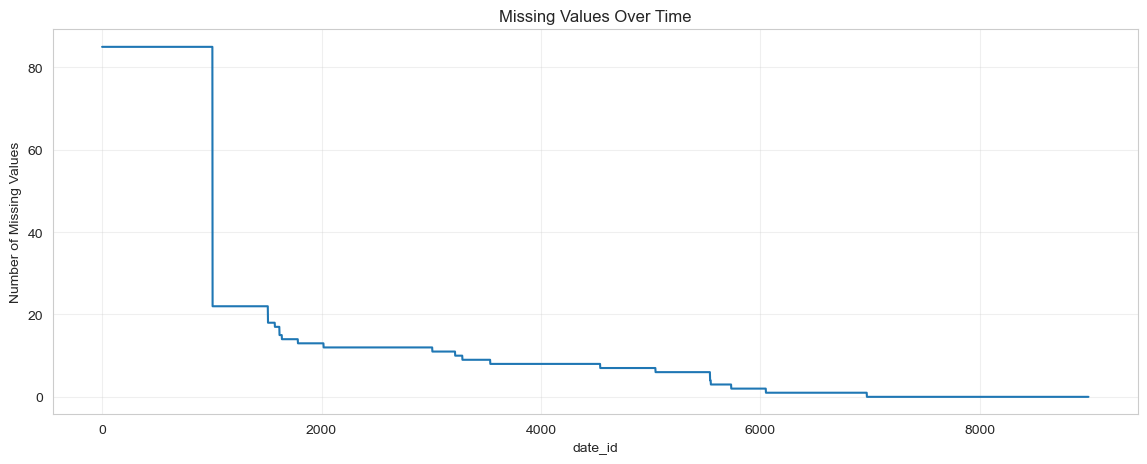

Early data (date_id < 1000): 85.0 missing/row
Recent data (date_id > 8000): 0.0 missing/row


In [13]:
# Plot missing values over time
missing_by_row = df_train.isnull().sum(axis=1)

plt.figure(figsize=(14, 5))
plt.plot(df_train['date_id'], missing_by_row)
plt.xlabel('date_id')
plt.ylabel('Number of Missing Values')
plt.title('Missing Values Over Time')
plt.grid(True, alpha=0.3)
plt.show()

print(f"Early data (date_id < 1000): {missing_by_row[df_train['date_id'] < 1000].mean():.1f} missing/row")
print(f"Recent data (date_id > 8000): {missing_by_row[df_train['date_id'] > 8000].mean():.1f} missing/row")

In [14]:
# Analyze feature groups
feature_groups = {}
for prefix in ['D', 'E', 'I', 'M', 'P', 'S', 'V']:
    cols = [c for c in df_train.columns if c.startswith(prefix) and c[1:].isdigit()]
    feature_groups[prefix] = cols
    print(f"{prefix} features: {len(cols)} columns")

print(f"\nTotal features: {sum(len(v) for v in feature_groups.values())}")

D features: 9 columns
E features: 20 columns
I features: 9 columns
M features: 18 columns
P features: 13 columns
S features: 12 columns
V features: 13 columns

Total features: 94


## 3. Convert to Qlib Format

In [16]:
# Initialize converter
converter = HullTacticalDataConverter(
    data_path='../data/raw/train.csv',
    output_path='../data/processed',
    instrument_name='SP500'
)

# Convert
df_qlib = converter.convert(start_date='1990-01-01')

print(f"Converted data shape: {df_qlib.shape}")
df_qlib.sample(5)

INFO:data_converter:Loading data from ../data/raw/train.csv
INFO:data_converter:Converted 8990 rows with 97 features
INFO:data_converter:Date range: 1990-01-01 00:00:00 to 2014-08-12 00:00:00
INFO:data_converter:Missing value ratio: 15.47%


Converted data shape: (8990, 99)


,date,instrument,D1,D2,D3,D4,D5,D6,D7,D8,...,V3,V4,V5,V6,V7,V8,V9,forward_returns,risk_free_rate,market_forward_excess_returns
7351,2010-02-16,SP500,0,0,0,1,0,0,1,0,...,0.458995,0.642196,-0.412938,0.634921,0.428512,0.416336,0.228894,-0.002000,0.000095,-0.002404
7069,2009-05-10,SP500,0,0,0,1,0,-1,0,0,...,0.558862,0.814153,0.674759,0.713624,-1.054648,0.981481,-1.204166,0.002122,0.000055,0.001759
2841,1997-10-12,SP500,0,0,0,1,1,0,0,1,...,0.049603,0.054233,-0.915737,0.000661,1.236150,0.000661,NaN,-0.021339,0.000166,-0.021816
6938,2008-12-30,SP500,0,0,0,0,0,0,0,0,...,0.832011,0.779101,1.734075,0.526455,-1.226994,0.779762,-1.214602,-0.000122,0.000040,-0.000471
215,1990-08-04,SP500,0,0,0,1,0,0,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.017865,0.000281,-0.018463


In [17]:
# Check date range
print(f"Date range: {df_qlib['date'].min()} to {df_qlib['date'].max()}")
print(f"Total days: {len(df_qlib)}")
print(f"Missing value ratio: {df_qlib.isnull().sum().sum() / (df_qlib.shape[0] * df_qlib.shape[1]):.2%}")

Date range: 1990-01-01 00:00:00 to 2014-08-12 00:00:00
Total days: 8990
Missing value ratio: 15.47%


## 4. Save for Qlib

In [18]:
# Save CSV for Qlib dump_bin.py
output_file = converter.save_for_qlib_dump(df_qlib, filename='SP500.csv')
print(f"Saved to: {output_file}")

INFO:data_converter:Saved Qlib-compatible CSV to ../data/processed/SP500.csv


Saved to: ../data/processed/SP500.csv


## 5. Get Feature Configuration

In [19]:
# Get feature config
config = converter.get_feature_config(df_qlib)

print("Feature groups:")
for group, features in config['features'].items():
    print(f"  {group}: {len(features)} features")
    print(f"    Example: {features[:3]}")

print(f"\nTarget variables: {config['targets']}")

Feature groups:
  D_features: 9 features
    Example: ['D1', 'D2', 'D3']
  E_features: 20 features
    Example: ['E1', 'E10', 'E11']
  I_features: 9 features
    Example: ['I1', 'I2', 'I3']
  M_features: 18 features
    Example: ['M1', 'M10', 'M11']
  P_features: 13 features
    Example: ['P1', 'P10', 'P11']
  S_features: 12 features
    Example: ['S1', 'S10', 'S11']
  V_features: 13 features
    Example: ['V1', 'V10', 'V11']

Target variables: ['forward_returns', 'risk_free_rate', 'market_forward_excess_returns']


## 6. Visualize Target Distribution

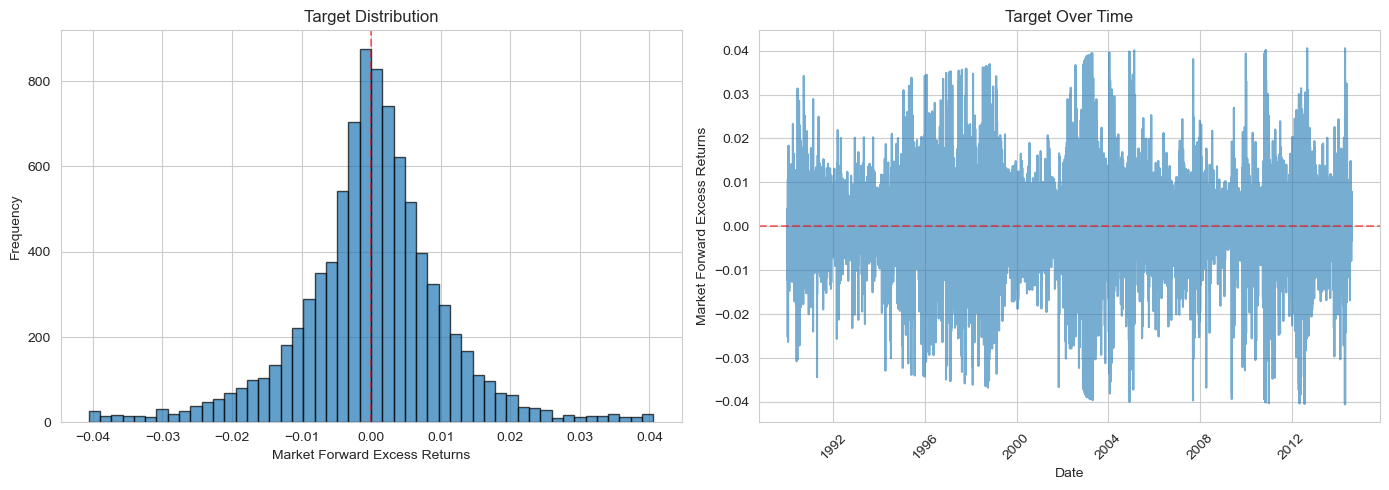

Target statistics:
count    8990.000000
mean        0.000051
std         0.010568
min        -0.040582
25%        -0.004759
50%         0.000252
75%         0.005479
max         0.040551
Name: market_forward_excess_returns, dtype: float64


In [20]:
# Plot target distribution
if 'market_forward_excess_returns' in df_qlib.columns:
    target = df_qlib['market_forward_excess_returns'].dropna()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram
    axes[0].hist(target, bins=50, alpha=0.7, edgecolor='black')
    axes[0].set_xlabel('Market Forward Excess Returns')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Target Distribution')
    axes[0].axvline(0, color='red', linestyle='--', alpha=0.5)
    
    # Time series
    axes[1].plot(df_qlib['date'], df_qlib['market_forward_excess_returns'], alpha=0.6)
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Market Forward Excess Returns')
    axes[1].set_title('Target Over Time')
    axes[1].axhline(0, color='red', linestyle='--', alpha=0.5)
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print(f"Target statistics:")
    print(target.describe())

## Next Steps

1. Run Qlib's `dump_bin.py` to convert CSV to binary format
2. Initialize Qlib with the converted data
3. Proceed to factor engineering (notebook 02)